# ScienceQA Visual Challenge — Optimized Notebook

**Strategy summary:**
- **Model**: `HuggingFaceTB/SmolVLM-500M-Instruct` (required by rules)
- **Fine-tuning**: QLoRA (4-bit NF4), LoRA r=16 on all attention projections — verified ≤5M trainable params
- **Inference**: Log-likelihood scoring over each choice letter (replaces unreliable generation)
- **Prompts**: lecture + hint + solution (chain-of-thought) during training
- **Augmentation**: Random choice-order shuffling to prevent positional bias
- **Final model**: Retrained on train+val combined before submission
- **Ensemble**: 3 seeds, average log-probs (optional section at bottom)

In [1]:
# ── 0. Install ────────────────────────────────────────────────────────────────
# transformers 4.47.1: Idefics3Processor works correctly, no vmap masking bug.
# The vmap-based masking_utils that crash with bitsandbytes 4-bit landed in 4.48.
!pip install -q transformers==4.47.1 peft==0.14.0 bitsandbytes accelerate datasets pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.8/374.8 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 74.6 MB/s eta 0:00:00


In [2]:
# ── 1. Imports & Configuration ────────────────────────────────────────────────
import os
import gc
import json
import random
from pathlib import Path
from functools import partial

import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset
from transformers import (
    Idefics3Processor,
    Idefics3ForConditionalGeneration,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR = Path("/kaggle/input/datasets/komvopoulos/finalexamdataset")

# ── Model & training knobs ────────────────────────────────────────────────────
MODEL_ID       = "HuggingFaceTB/SmolVLM-500M-Instruct"
IMG_SIZE       = 384
LORA_R         = 8
LORA_ALPHA     = 16
LORA_DROPOUT   = 0.05
LR             = 1e-4
NUM_EPOCHS     = 3
# do_image_splitting=True produces ~5× more visual tokens per image.
# Reduce to BATCH_SIZE=1, GRAD_ACCUM=16 to keep effective batch=16 within 16 GB VRAM.
BATCH_SIZE     = 1
GRAD_ACCUM     = 16
CHOICE_LETTERS = "ABCDEFGHIJ"
PARAM_BUDGET   = 5_000_000

# ── Text-field limits ─────────────────────────────────────────────────────────
INCLUDE_LECTURE     = True
LECTURE_MAX_CHARS   = 1000
SOLUTION_MAX_CHARS  = 400
TRAIN_WITH_SOLUTION = False

# ── Cross-session checkpoint resume ──────────────────────────────────────────
RESUME_CHECKPOINT_PATH = None

# ── System prompt (ChatML format) ─────────────────────────────────────────────
SYSTEM_PROMPT = (
    "You are an expert science educator. "
    "Carefully analyze the image and all provided context, "
    "then select the single best answer from the choices."
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

2026-05-06 02:48:48.785021: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778035729.015833      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778035729.079741      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778035729.627520      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778035729.627582      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778035729.627585      23 computation_placer.cc:177] computation placer alr

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Load Data

In [3]:
# ── 2a. Load CSVs ─────────────────────────────────────────────────────────────
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

for df in [train_df, val_df, test_df]:
    df["choices"] = df["choices"].apply(json.loads)

# Detect whether solution is available at test time.
# In ScienceQA the test split typically omits solutions since they reveal the answer.
# We check dynamically so the code works either way.
TEST_HAS_SOLUTION = (
    "solution" in test_df.columns
    and test_df["solution"].notna().any()
    and test_df["solution"].astype(str).str.strip().ne("").any()
)
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"Solution available in test.csv: {TEST_HAS_SOLUTION}")
print(f"Test columns: {test_df.columns.tolist()}")
train_df.head(2)

Train: 3,109 | Val: 1,048 | Test: 1,008
Solution available in test.csv: False
Test columns: ['id', 'image_path', 'question', 'choices', 'num_choices', 'hint', 'lecture', 'task', 'grade', 'subject', 'topic', 'category', 'skill']


,id,image_path,question,choices,num_choices,answer,hint,lecture,solution,task,grade,subject,topic,category,skill
0,train_07667,images/train/train_07667.png,Why might putting each tadpole in its own pool...,[the male's tadpoles will be larger when they ...,3,2,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...
1,train_02628,images/train/train_02628.png,Why might forming strong social bonds with oth...,"[the female's offspring will live longer, the ...",3,0,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...


In [4]:
# ── Dataset feature audit ─────────────────────────────────────────────────────
# Run this cell to see every available column: fill rate, unique values, samples.

for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n{'='*70}")
    print(f"  {split_name.upper()}  —  {len(df):,} rows  ×  {len(df.columns)} columns")
    print(f"{'='*70}")
    for col in df.columns:
        series = df[col]
        n_null  = series.isna().sum()

        first_valid = series.dropna().iloc[0] if series.notna().any() else None
        is_list_col = isinstance(first_valid, list)

        n_empty = (series.astype(str).str.strip() == "").sum() if not is_list_col else 0
        fill    = 100 * (1 - (n_null + n_empty) / len(df))
        dtype   = str(series.dtype)

        if is_list_col:
            uniq = "n/a (list)"
        else:
            try:
                uniq = series.nunique(dropna=True)
            except TypeError:
                uniq = "unhashable"

        samples = series.dropna().head(3).tolist()
        sample_str = " | ".join(repr(str(v)[:60]) for v in samples)

        print(f"\n  [{col}]  dtype={dtype}  fill={fill:.1f}%  unique={uniq}")
        print(f"    samples: {sample_str}")

        if isinstance(uniq, int) and uniq <= 20 and col not in ("id", "answer", "image_path"):
            vc = series.value_counts(dropna=False).head(10)
            for val, cnt in vc.items():
                bar = "█" * int(20 * cnt / len(df))
                print(f"    {str(val):<30} {cnt:5d}  {bar}")

print(f"\n{'='*70}")
print("  FIELDS USED IN PROMPT:")
print(f"    subject, topic, category, grade  (metadata header)")
print(f"    skill                            (cognitive objective)")
print(f"    lecture  (INCLUDE_LECTURE={INCLUDE_LECTURE})")
print(f"    hint     (always included when present)")
print(f"    solution (EXCLUDED — TRAIN_WITH_SOLUTION={TRAIN_WITH_SOLUTION}, TEST_HAS_SOLUTION={{}})")
print(f"  FIELDS NOT USED IN PROMPT:")
print(f"    num_choices, task  (redundant)")
print(f"{'='*70}")


  TRAIN  —  3,109 rows  ×  15 columns

  [id]  dtype=object  fill=100.0%  unique=3109
    samples: 'train_07667' | 'train_02628' | 'train_00927'

  [image_path]  dtype=object  fill=100.0%  unique=3109
    samples: 'images/train/train_07667.png' | 'images/train/train_02628.png' | 'images/train/train_00927.png'

  [question]  dtype=object  fill=100.0%  unique=1150
    samples: 'Why might putting each tadpole in its own pool of water incr' | 'Why might forming strong social bonds with other females inc' | 'Why might raising cubs with other lionesses in a pride incre'

  [choices]  dtype=object  fill=100.0%  unique=n/a (list)
    samples: '["the male\'s tadpoles will be larger when they hatch", \'the ' | '["the female\'s offspring will live longer", \'the female will' | '["the lioness\'s cubs will be around other cubs", "the liones'

  [num_choices]  dtype=int64  fill=100.0%  unique=4
    samples: '3' | '3' | '3'
    3                               1552  █████████
    4                   

## 3. Load Model with QLoRA

The parameter budget is **5 million trainable params**. With `r=16` on the four attention projections (`q, k, v, o`) of SmolVLM-500M's language backbone this lands at roughly 2–4 M params — safely within budget. `model.print_trainable_parameters()` shows the exact count. If it exceeds 5 M, change `LORA_R = 8`.

In [5]:
# ── 3. Load SmolVLM-500M with 4-bit QLoRA ────────────────────────────────────

def load_model_and_processor(model_id: str = MODEL_ID, lora_r: int = LORA_R):
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    proc = Idefics3Processor.from_pretrained(model_id)
    if proc.tokenizer.pad_token is None:
        proc.tokenizer.pad_token = proc.tokenizer.eos_token
    proc.tokenizer.padding_side = "right"

    # Enable image splitting: each image is processed as 4 tiles + 1 global view
    # (5 passes through SigLIP). Gives the model fine-grained detail on diagrams,
    # labels, and small text — critical for science QA. Default is False for 500M.
    # Tradeoff: ~5× more visual tokens → BATCH_SIZE reduced to 1 to avoid OOM.
    proc.image_processor.do_image_splitting = True

    base = Idefics3ForConditionalGeneration.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        device_map="auto",
        torch_dtype=torch.float16,
        low_cpu_mem_usage=True,
    )
    base = prepare_model_for_kbit_training(base, use_gradient_checkpointing=True)

    lora_cfg = LoraConfig(
        r=lora_r,
        lora_alpha=LORA_ALPHA,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "up_proj", "down_proj"],
        lora_dropout=LORA_DROPOUT,
        bias="none",
        task_type="CAUSAL_LM",
    )
    mdl = get_peft_model(base, lora_cfg)
    mdl.enable_input_require_grads()

    trainable, total = mdl.get_nb_trainable_parameters()
    print(f"Trainable params : {trainable:,} / {total:,}  ({100 * trainable / total:.3f}%)")
    assert trainable <= PARAM_BUDGET, (
        f"Trainable params {trainable:,} exceed budget {PARAM_BUDGET:,}. "
        "Reduce LORA_R and re-run."
    )
    print(f"image_splitting  : {proc.image_processor.do_image_splitting}")
    print(f"padding_side     : {proc.tokenizer.padding_side}")
    print(f"pad_token_id     : {proc.tokenizer.pad_token_id}  ({proc.tokenizer.pad_token!r})")
    print(f"eos_token_id     : {proc.tokenizer.eos_token_id}  ({proc.tokenizer.eos_token!r})")
    return mdl, proc


model, processor = load_model_and_processor()

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Some kwargs in processor config are unused and will not have any effect: image_seq_len. 


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Trainable params : 4,784,128 / 512,266,432  (0.934%)
image_splitting  : True
padding_side     : right
pad_token_id     : 2  ('<|im_end|>')
eos_token_id     : 49279  ('<end_of_utterance>')


In [6]:
# ── 2b. Prompt Engineering ────────────────────────────────────────────────────
# Uses SmolVLM's NATIVE chat template via processor.apply_chat_template.
#
# Why this matters: SmolVLM-500M-Instruct was instruction-tuned on a specific
# format (User: / Assistant: with <end_of_utterance> separators). The previous
# code used custom ChatML (<|im_start|>system/user/assistant ... <|im_end|>),
# which the model was NEVER pretrained on. LoRA was wasting capacity learning
# a foreign template instead of the science task. Switching to the native
# template lets LoRA focus on the actual task — likely the main reason the
# previous run capped at 79%.
#
# A verification cell (immediately after cell-load-model) prints the actual
# tokenizer.chat_template + a sample build_prompt output to confirm the format.

def _trunc(text: str, max_chars: int) -> str:
    text = str(text).strip()
    return text if len(text) <= max_chars else text[:max_chars] + "…"


def _get(row, key: str, default=""):
    """Safely read a field from either a dict or a pandas row."""
    if isinstance(row, dict):
        val = row.get(key, default)
    else:
        val = getattr(row, key, default)
    return default if val is None or (isinstance(val, float) and val != val) else val


def _build_user_text(row, include_solution: bool) -> str:
    """Build the text that goes inside the user message (after the <image>).
    SmolVLM has no native system role, so SYSTEM_PROMPT is prepended here."""
    parts = [SYSTEM_PROMPT]

    # Metadata header
    meta_parts = []
    for key, label in [("subject",  "Subject"),
                       ("topic",    "Topic"),
                       ("category", "Category"),
                       ("grade",    "Grade")]:
        val = str(_get(row, key, "")).strip()
        if val:
            if key == "grade":
                val = val.replace("grade", "Grade ")
            meta_parts.append(f"{label}: {val}")

    skill = str(_get(row, "skill", "")).strip()

    meta_lines = []
    if meta_parts:
        meta_lines.append(" | ".join(meta_parts))
    if skill:
        meta_lines.append(f"Skill: {skill}")
    if meta_lines:
        parts.append("\n".join(meta_lines))

    # Context block
    context_parts = []
    if INCLUDE_LECTURE:
        lecture = str(_get(row, "lecture", "")).strip()
        if lecture:
            context_parts.append(_trunc(lecture, LECTURE_MAX_CHARS))

    hint = str(_get(row, "hint", "")).strip()
    if hint:
        context_parts.append(hint)

    if include_solution:
        sol = str(_get(row, "solution", "")).strip()
        if sol:
            context_parts.append("Reasoning: " + _trunc(sol, SOLUTION_MAX_CHARS))

    if context_parts:
        parts.append("Context:\n" + "\n\n".join(context_parts))

    # Question and choices
    choices = _get(row, "choices", [])
    if not isinstance(choices, list):
        choices = []
    choices_str = "\n".join(
        f"  {CHOICE_LETTERS[i]}. {c}" for i, c in enumerate(choices)
    )
    question = str(_get(row, "question", "")).strip()

    parts.append(f"Question: {question}\nChoices:\n{choices_str}")

    return "\n\n".join(parts)


def build_prompt(row, include_answer: bool = False, include_solution: bool = False) -> str:
    """
    Output (SmolVLM native template):
      User:<image>{user_text}<end_of_utterance>
      Assistant:                                ← include_answer=False (inference base)
      Assistant: X<end_of_utterance>            ← include_answer=True  (training)

    Requires the global `processor` (loaded in cell-load-model). Sanity-print
    of an actual sample is in the verification cell after cell-load-model.
    """
    proc = globals().get("processor")
    if proc is None:
        raise RuntimeError(
            "processor not loaded — run cell-load-model before calling build_prompt"
        )

    user_text = _build_user_text(row, include_solution)

    messages = [{"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": user_text},
    ]}]

    if include_answer:
        letter = CHOICE_LETTERS[int(_get(row, "answer"))]
        messages.append({"role": "assistant", "content": [
            {"type": "text", "text": letter},
        ]})

    prompt = proc.apply_chat_template(
        messages,
        add_generation_prompt=not include_answer,
    )

    # Strip trailing newline so the answer letter (or "Assistant:") sits at the
    # very end. The collate walk-back skips pad/eos tokens and lands on the
    # answer letter — a stray trailing \n would break that.
    return prompt.rstrip("\n")

In [7]:
# ── 3b. Chat-template verification ────────────────────────────────────────────
# Confirm that build_prompt's output matches SmolVLM's INSTRUCTION-TUNED chat
# template — the format the model was actually trained on. Mismatch here is
# the suspected reason the previous custom-ChatML run capped at 79%.

print("=" * 75)
print("  STEP 1: tokenizer.chat_template (the ground truth)")
print("=" * 75)
template = processor.tokenizer.chat_template
if template:
    print(template[:900] + ("..." if len(template) > 900 else ""))
else:
    print("(no chat_template defined on tokenizer — unexpected!)")

print("\n" + "=" * 75)
print("  STEP 2: apply_chat_template OUTPUT for a tiny test message")
print("=" * 75)
test_msgs_inf = [{"role": "user", "content": [
    {"type": "image"},
    {"type": "text", "text": "What is shown?"},
]}]
test_msgs_train = test_msgs_inf + [
    {"role": "assistant", "content": [{"type": "text", "text": "A"}]},
]
ref_inf   = processor.apply_chat_template(test_msgs_inf,   add_generation_prompt=True)
ref_train = processor.apply_chat_template(test_msgs_train, add_generation_prompt=False)
print("\n--- For inference (add_generation_prompt=True) ---")
print(repr(ref_inf))
print(ref_inf)
print("\n--- For training (with assistant answer 'A') ---")
print(repr(ref_train))
print(ref_train)

print("\n" + "=" * 75)
print("  STEP 3: OUR build_prompt() on a real training row")
print("=" * 75)
sample_row = train_df.iloc[0].to_dict()
our_inf   = build_prompt(sample_row, include_answer=False, include_solution=False)
our_train = build_prompt(sample_row, include_answer=True,  include_solution=False)
print(f"\n--- Our inference prompt ({len(our_inf)} chars) — last 300 chars ---")
print(our_inf[-300:])
print(f"\n--- Our training prompt ({len(our_train)} chars) — last 300 chars ---")
print(our_train[-300:])

print("\n" + "=" * 75)
print("  STEP 4: Format checks (vs. SmolVLM's expected layout)")
print("=" * 75)
checks = [
    ("Inference prompt ends with 'Assistant:' (ready for letter)",
     our_inf.endswith("Assistant:")),
    ("Training prompt ends with '<end_of_utterance>' (after answer)",
     our_train.endswith("<end_of_utterance>")),
    ("Uses 'User:' (capitalized, inline — not '<|im_start|>user\\n')",
     "User:" in our_inf and "<|im_start|>user" not in our_inf),
    ("Uses 'Assistant:' (capitalized, inline)",
     "Assistant:" in our_inf),
    ("Uses <end_of_utterance> as message separator",
     "<end_of_utterance>" in our_inf),
    ("<image> placeholder appears INLINE right after 'User:'",
     "User:<image>" in our_inf),
    ("Does NOT use <|im_end|> as message separator (old ChatML)",
     "<|im_end|>" not in our_inf),
    ("Does NOT inject a 'system' role tag (SmolVLM has no system role)",
     "<|im_start|>system" not in our_inf),
]

all_ok = True
print()
for label, ok in checks:
    icon = "OK  " if ok else "FAIL"
    print(f"  [{icon}] {label}")
    all_ok = all_ok and ok

print()
if all_ok:
    print("  ALL CHECKS PASSED — build_prompt matches SmolVLM's instruction format.")
    print("  This is the format the base model was trained to understand.")
else:
    print("  ONE OR MORE CHECKS FAILED — DO NOT TRAIN until build_prompt is fixed.")

  STEP 1: tokenizer.chat_template (the ground truth)
<|im_start|>{% for message in messages %}{{message['role'] | capitalize}}{% if message['content'][0]['type'] == 'image' %}{{':'}}{% else %}{{': '}}{% endif %}{% for line in message['content'] %}{% if line['type'] == 'text' %}{{line['text']}}{% elif line['type'] == 'image' %}{{ '<image>' }}{% endif %}{% endfor %}<end_of_utterance>
{% endfor %}{% if add_generation_prompt %}{{ 'Assistant:' }}{% endif %}

  STEP 2: apply_chat_template OUTPUT for a tiny test message

--- For inference (add_generation_prompt=True) ---
'<|im_start|>User:<image>What is shown?<end_of_utterance>\nAssistant:'
<|im_start|>User:<image>What is shown?<end_of_utterance>
Assistant:

--- For training (with assistant answer 'A') ---
'<|im_start|>User:<image>What is shown?<end_of_utterance>\nAssistant: A<end_of_utterance>\n'
<|im_start|>User:<image>What is shown?<end_of_utterance>
Assistant: A<end_of_utterance>


  STEP 3: OUR build_prompt() on a real training row

--- 

In [8]:
# ── 2c. Dataset with choice-order augmentation ────────────────────────────────

class ScienceQADataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        data_dir: Path,
        img_size: int = IMG_SIZE,
        is_train: bool = True,
        augment_choices: bool = False,
        include_solution: bool = False,
    ):
        self.df               = df.reset_index(drop=True)
        self.data_dir         = data_dir
        self.img_size         = img_size
        self.is_train         = is_train
        self.augment_choices  = augment_choices
        self.include_solution = include_solution

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int) -> dict:
        row = self.df.iloc[idx].to_dict()

        img = Image.open(self.data_dir / "images" / row["image_path"]).convert("RGB")
        # thumbnail() preserves aspect ratio (fits within img_size × img_size).
        # resize() forces a square and distorts non-square diagrams/charts/maps.
        img.thumbnail((self.img_size, self.img_size), Image.BICUBIC)

        if self.augment_choices and self.is_train:
            choices = list(row["choices"])
            answer  = int(row["answer"])
            perm    = list(range(len(choices)))
            random.shuffle(perm)
            row["choices"] = [choices[p] for p in perm]
            row["answer"]  = perm.index(answer)

        if self.is_train:
            return {
                "image": img,
                "text":  build_prompt(row, include_answer=True,
                                      include_solution=self.include_solution),
                "answer": int(row["answer"]),
            }
        else:
            return {
                "image":   img,
                "text":    build_prompt(row, include_answer=False,
                                        include_solution=self.include_solution),
                "choices": row["choices"],
                "answer":  int(row["answer"]) if "answer" in row and pd.notna(row.get("answer")) else -1,
                "id":      row.get("id", ""),
            }

train_ds = ScienceQADataset(train_df, DATA_DIR, is_train=True,
                            augment_choices=True,
                            include_solution=TRAIN_WITH_SOLUTION)
val_ds   = ScienceQADataset(val_df,   DATA_DIR, is_train=False,
                            include_solution=TEST_HAS_SOLUTION)
test_ds  = ScienceQADataset(test_df,  DATA_DIR, is_train=False,
                            include_solution=TEST_HAS_SOLUTION)

print(f"Datasets — train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)}")

Datasets — train: 3109 | val: 1048 | test: 1008


/tmp/ipykernel_23/631102028.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


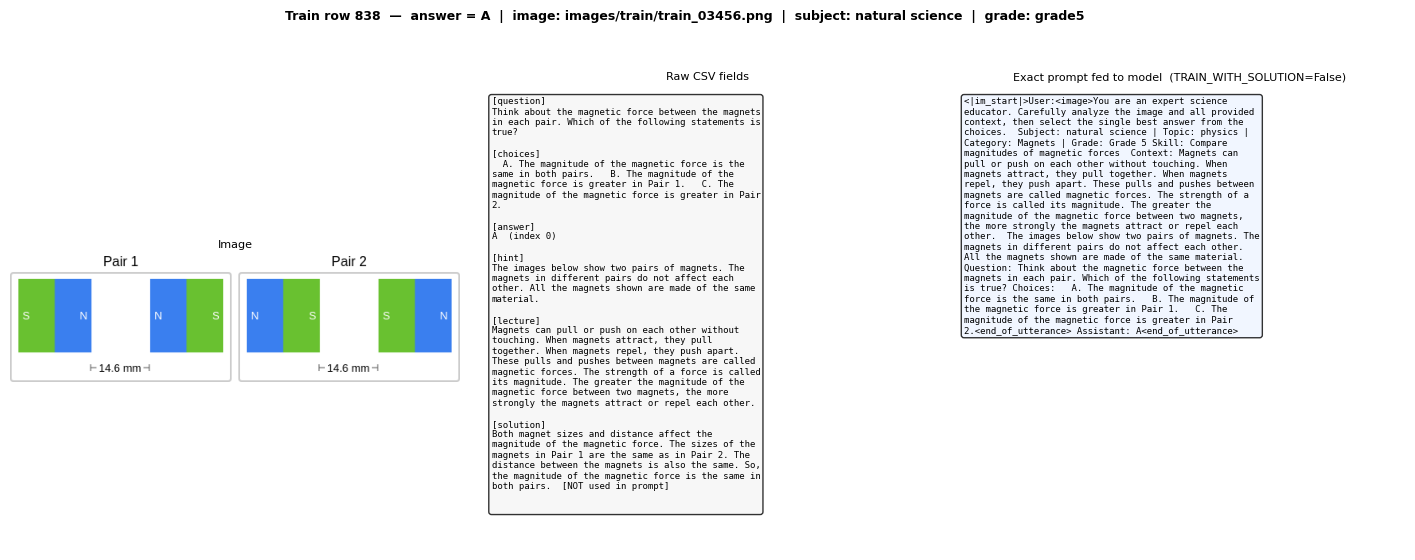

  Row  838 | tokens: 254



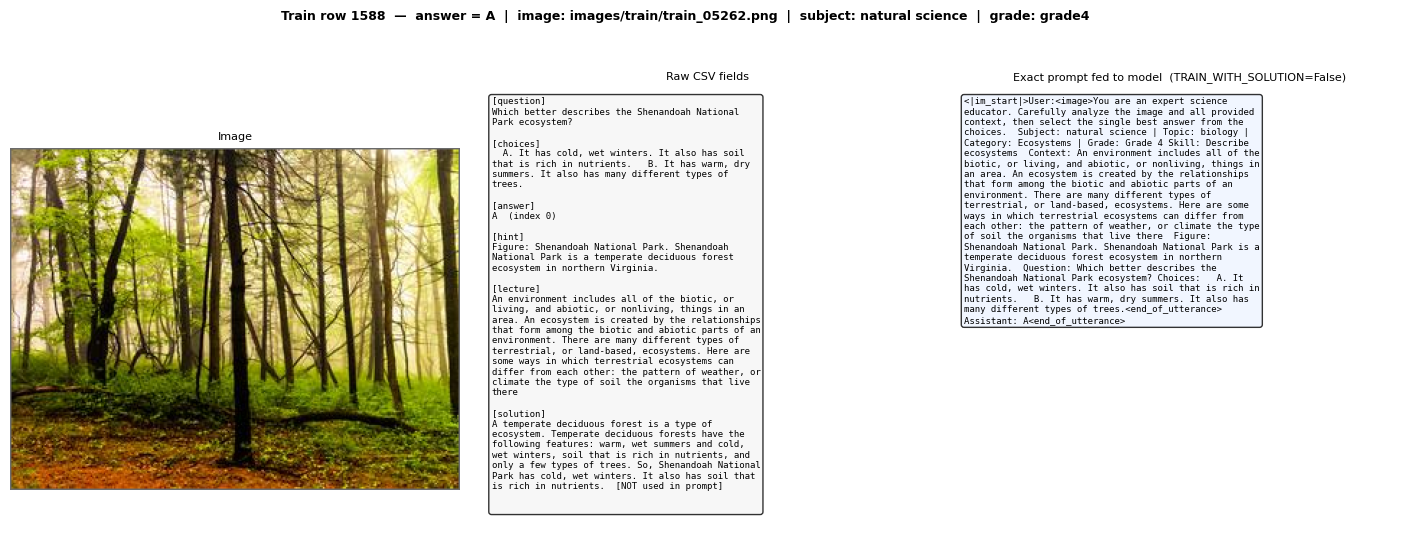

  Row 1588 | tokens: 244



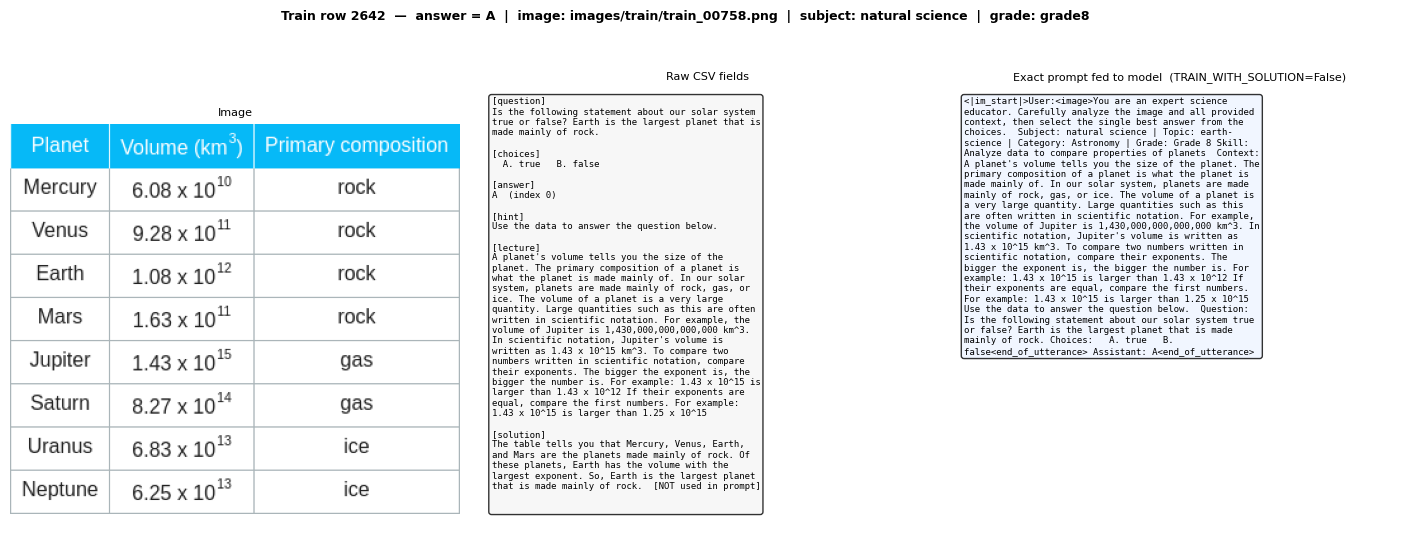

  Row 2642 | tokens: 355



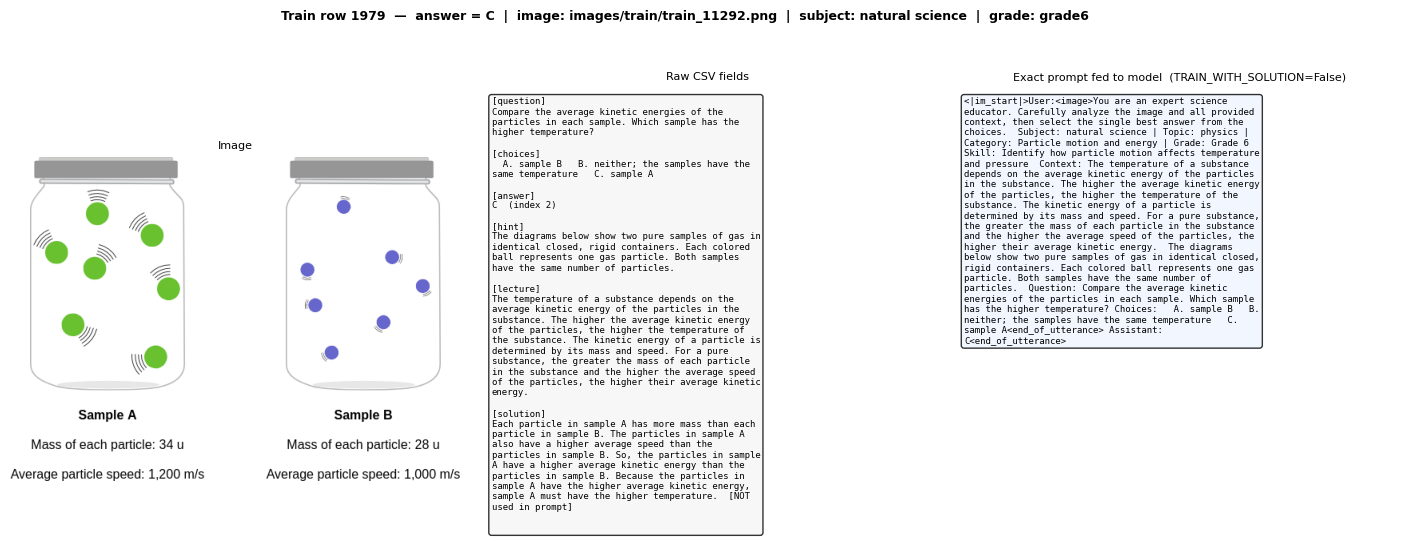

  Row 1979 | tokens: 243



In [9]:
# ── Sample viewer — inspect training examples + their actual prompts ──────────
# Shows N samples: raw fields on the left, exact training prompt on the right.
# Change SHOW_N or SAMPLE_INDICES to inspect specific rows.

import textwrap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

SHOW_N         = 4       # how many samples to display
SAMPLE_INDICES = None    # None = random; or e.g. [0, 5, 100, 200] for specific rows

rng = np.random.default_rng(0)
indices = (
    SAMPLE_INDICES
    if SAMPLE_INDICES is not None
    else rng.choice(len(train_df), size=SHOW_N, replace=False).tolist()
)

def _wrap(text, width=52):
    return "\n".join(textwrap.wrap(str(text), width))

for idx in indices:
    row = train_df.iloc[idx].to_dict()

    img_path = DATA_DIR / "images" / row["image_path"]
    img = (
        Image.open(img_path).convert("RGB")
        if img_path.exists()
        else Image.new("RGB", (224, 224), (180, 180, 180))
    )

    actual_prompt = build_prompt(row, include_answer=True,
                                 include_solution=TRAIN_WITH_SOLUTION)
    answer_letter = CHOICE_LETTERS[int(row["answer"])]

    fig = plt.figure(figsize=(18, 6))
    fig.suptitle(
        f"Train row {idx}  —  answer = {answer_letter}  |  "
        f"image: {row['image_path']}  |  subject: {row.get('subject','?')}  |  "
        f"grade: {row.get('grade','?')}",
        fontsize=9, fontweight="bold", y=1.01,
    )
    gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.05)

    ax_img = fig.add_subplot(gs[0])
    ax_img.imshow(img)
    ax_img.axis("off")
    ax_img.set_title("Image", fontsize=8)

    ax_raw = fig.add_subplot(gs[1])
    ax_raw.axis("off")
    fields = [
        ("question", row.get("question", "")),
        ("choices",  "\n".join(f"  {CHOICE_LETTERS[i]}. {c}"
                               for i, c in enumerate(row["choices"]))),
        ("answer",   f"{answer_letter}  (index {row['answer']})"),
        ("hint",     row.get("hint", "—")),
        ("lecture",  row.get("lecture", "—")),
        ("solution", row.get("solution", "—") + "  [NOT used in prompt]"),
    ]
    raw_text = ""
    for label, value in fields:
        raw_text += f"[{label}]\n{_wrap(value, 50)}\n\n"
    ax_raw.text(
        0.02, 0.98, raw_text,
        transform=ax_raw.transAxes,
        va="top", ha="left", fontsize=6.5,
        fontfamily="monospace",
        bbox=dict(boxstyle="round", facecolor="#f5f5f5", alpha=0.8),
    )
    ax_raw.set_title("Raw CSV fields", fontsize=8)

    ax_prompt = fig.add_subplot(gs[2])
    ax_prompt.axis("off")
    ax_prompt.text(
        0.02, 0.98, _wrap(actual_prompt, 55),
        transform=ax_prompt.transAxes,
        va="top", ha="left", fontsize=6.5,
        fontfamily="monospace",
        bbox=dict(boxstyle="round", facecolor="#eef4ff", alpha=0.8),
    )
    ax_prompt.set_title(
        f"Exact prompt fed to model  (TRAIN_WITH_SOLUTION={TRAIN_WITH_SOLUTION})",
        fontsize=8,
    )

    plt.tight_layout()
    plt.show()

    n_tok = len(processor.tokenizer(actual_prompt)["input_ids"])
    print(f"  Row {idx:4d} | tokens: {n_tok}")
    print()

In [10]:
# ── 4. Collate function — answer-token label masking ─────────────────────────
#
# SmolVLM training text ends:  "...Assistant: X<end_of_utterance>"
# After right-padding:         "...X<end_of_utterance><|im_end|><|im_end|>..."
#
# Walk backward past PAD (<|im_end|>, id 2) and EOS (<end_of_utterance>, id
# 49279) to land on the answer-letter token X. Label only that one position;
# everything else is -100 (ignored by the loss).
#
# The walk-back also handles middle-of-sequence <end_of_utterance> tokens
# correctly: it stops at the FIRST non-skip token from the right, which is X.

def collate_fn(batch, proc):
    texts  = [item["text"]  for item in batch]
    images = [item["image"] for item in batch]

    proc.tokenizer.padding_side = "right"
    inputs = proc(text=texts, images=images, return_tensors="pt", padding=True)

    eos_id    = proc.tokenizer.eos_token_id      # <end_of_utterance>
    pad_id    = proc.tokenizer.pad_token_id      # <|im_end|>
    im_end_id = proc.tokenizer.convert_tokens_to_ids("<|im_end|>")
    skip_ids  = {eos_id, pad_id, im_end_id}

    labels = torch.full_like(inputs["input_ids"], -100)

    for i in range(labels.shape[0]):
        seq = inputs["input_ids"][i].tolist()

        answer_pos = len(seq) - 1
        while answer_pos >= 0 and seq[answer_pos] in skip_ids:
            answer_pos -= 1

        if answer_pos >= 0:
            labels[i, answer_pos] = inputs["input_ids"][i, answer_pos]

    inputs["labels"] = labels
    return inputs


_collate = partial(collate_fn, proc=processor)

In [11]:
# ── 4b. Pre-training sanity checks ───────────────────────────────────────────
# Runs BEFORE training. All checks must pass (no "FAIL" lines) before proceeding.
#
# CHECK A: collate_fn label positions — verifies the answer token is found.
# CHECK B: forward-pass loss — verifies the initial loss is finite and >0.
#
# If CHECK A fails: the collate_fn cannot find the answer token (padding bug).
# If CHECK B fails: labels are all -100 (loss=NaN) or model is broken.

print(f"{'='*65}")
print(f" Tokenizer  padding_side : {processor.tokenizer.padding_side}")
print(f"            pad_token_id : {processor.tokenizer.pad_token_id}")
print(f"            eos_token_id : {processor.tokenizer.eos_token_id}")
print(f"{'='*65}\n")

# ── CHECK A: label positions ──────────────────────────────────────────────────
print("── CHECK A: label positions ─────────────────────────────────────────")
_items = [train_ds[i] for i in range(4)]
_batch = _collate(_items)

eos_id = processor.tokenizer.eos_token_id
pad_id = processor.tokenizer.pad_token_id
check_a_ok = True

for i, item in enumerate(_items):
    seq    = _batch["input_ids"][i].tolist()
    labels = _batch["labels"][i].tolist()
    labeled = [p for p, l in enumerate(labels) if l != -100]
    expected = CHOICE_LETTERS[item["answer"]]

    print(f"  Sample {i}  (expected: {expected})")
    print(f"    seq length     : {len(seq)}")
    print(f"    labeled pos(s) : {labeled}")

    # Last 6 real tokens
    last_real = [p for p, m in enumerate(_batch["attention_mask"][i].tolist()) if m == 1][-6:]
    tokens_str = [(processor.tokenizer.decode([seq[p]]), seq[p]) for p in last_real]
    print(f"    last 6 tokens  : {tokens_str}")

    if len(labeled) == 0:
        print(f"    FAIL: no labeled position — collate_fn did not find the answer token")
        check_a_ok = False
    elif len(labeled) > 1:
        print(f"    FAIL: {len(labeled)} labeled positions (expected 1)")
        check_a_ok = False
    else:
        pos    = labeled[0]
        tok_id = seq[pos]
        tok_str = processor.tokenizer.decode([tok_id]).strip()
        if tok_id in (eos_id, pad_id):
            print(f"    FAIL: labeled token id={tok_id} is EOS or PAD, not a letter")
            check_a_ok = False
        elif tok_str.upper() != expected:
            print(f"    FAIL: decoded '{tok_str}' != expected '{expected}'")
            check_a_ok = False
        else:
            print(f"    OK  : token '{tok_str}' at pos {pos} matches '{expected}'")
    print()

# ── CHECK B: forward-pass loss ────────────────────────────────────────────────
print("── CHECK B: forward-pass loss ───────────────────────────────────────")
model.eval()
with torch.no_grad():
    _dev_batch = {k: v.to(model.device) if torch.is_tensor(v) else v
                  for k, v in _batch.items()}
    out = model(**_dev_batch)
    loss_val = out.loss.item()

if loss_val != loss_val:  # NaN check
    print(f"  FAIL: loss = NaN — labels are probably all -100 (collate_fn bug)")
    check_b_ok = False
elif loss_val < 0.01:
    print(f"  FAIL: loss = {loss_val:.4f} — suspiciously near zero before any training")
    check_b_ok = False
elif loss_val > 20:
    print(f"  WARN: loss = {loss_val:.4f} — unusually high (check inputs)")
    check_b_ok = True
else:
    print(f"  OK  : initial loss = {loss_val:.4f}  (expected ~2–5 for a random model)")
    check_b_ok = True
model.train()

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
if check_a_ok and check_b_ok:
    print("  ALL CHECKS PASSED — safe to proceed to training")
else:
    print("  ONE OR MORE CHECKS FAILED — DO NOT PROCEED until fixed")
print(f"{'='*65}")

 Tokenizer  padding_side : right
            pad_token_id : 2
            eos_token_id : 49279

── CHECK A: label positions ─────────────────────────────────────────
  Sample 0  (expected: C)
    seq length     : 1692
    labeled pos(s) : [1690]
    last 6 tokens  : [('\n', 198), ('Ass', 9519), ('istant', 9531), (':', 42), (' C', 340), ('<end_of_utterance>', 49279)]
    OK  : token 'C' at pos 1690 matches 'C'

  Sample 1  (expected: C)
    seq length     : 1692
    labeled pos(s) : [1664]
    last 6 tokens  : [('\n', 198), ('Ass', 9519), ('istant', 9531), (':', 42), (' C', 340), ('<end_of_utterance>', 49279)]
    OK  : token 'C' at pos 1664 matches 'C'

  Sample 2  (expected: A)
    seq length     : 1692
    labeled pos(s) : [1398]
    last 6 tokens  : [('\n', 198), ('Ass', 9519), ('istant', 9531), (':', 42), (' A', 330), ('<end_of_utterance>', 49279)]
    OK  : token 'A' at pos 1398 matches 'A'

  Sample 3  (expected: A)
    seq length     : 1692
    labeled pos(s) : [1668]
    last 6

## 4. Training — Development Run

Train on `train_df`, evaluate on `val_df`. Use this to confirm the model learns and to pick the best epoch checkpoint. The `load_best_model_at_end=True` flag restores the lowest-val-loss checkpoint automatically.

In [12]:
# ── 4c. Smoke test — 50 samples × 1 epoch (~5 min on T4) ─────────────────────
from transformers import TrainerCallback

class VerboseCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or "loss" not in logs:
            return
        loss  = logs["loss"]
        step  = state.global_step
        epoch = logs.get("epoch", "?")
        lr    = logs.get("learning_rate", float("nan"))
        if loss != loss:
            print(f"  Step {step:4d} | epoch {epoch} | loss = NaN  ← labels may all be -100")
        elif loss < 1e-4:
            print(f"  Step {step:4d} | epoch {epoch} | loss = {loss:.6f}  ← suspiciously low")
        else:
            print(f"  Step {step:4d} | epoch {epoch} | loss = {loss:.4f} | lr = {lr:.2e}")


smoke_ds = ScienceQADataset(
    train_df.head(50), DATA_DIR,
    is_train=True, augment_choices=False,
    include_solution=TEST_HAS_SOLUTION,
)

smoke_args = TrainingArguments(
    output_dir           = "./smoke-test",
    num_train_epochs     = 1,
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 2,
    learning_rate        = LR,
    lr_scheduler_type    = "cosine",
    warmup_ratio         = 0.1,
    fp16                 = True,
    bf16                 = False,
    gradient_checkpointing = True,
    gradient_checkpointing_kwargs = {"use_reentrant": False},
    save_strategy        = "no",
    eval_strategy        = "no",
    logging_steps        = 5,
    dataloader_num_workers = 0,
    remove_unused_columns  = False,
    report_to            = "none",
)

model.config.use_cache = False

smoke_trainer = Trainer(
    model        = model,
    args         = smoke_args,
    train_dataset= smoke_ds,
    data_collator= _collate,
    callbacks    = [VerboseCallback()],
)

print("=== SMOKE TEST START (50 samples, 1 epoch) ===")
smoke_trainer.train()
print("=== SMOKE TEST DONE ===")

=== SMOKE TEST START (50 samples, 1 epoch) ===


Step,Training Loss
5,6.120400
10,4.271100


  Step    5 | epoch 0.4 | loss = 6.1204 | lr = 1.00e-04
  Step   10 | epoch 0.8 | loss = 4.2711 | lr = 5.00e-05
=== SMOKE TEST DONE ===


In [13]:
# # ── 5. Dev training run ───────────────────────────────────────────────────────
# del model
# gc.collect()
# torch.cuda.empty_cache()

# model, processor = load_model_and_processor()
# _collate = partial(collate_fn, proc=processor)

# training_args_dev = TrainingArguments(
#     output_dir                  = "./qlora-dev",
#     num_train_epochs            = NUM_EPOCHS,
#     per_device_train_batch_size = BATCH_SIZE,
#     gradient_accumulation_steps = GRAD_ACCUM,
#     learning_rate               = LR,
#     weight_decay                = 0.01,
#     lr_scheduler_type           = "cosine",
#     warmup_ratio                = 0.1,
#     fp16                        = True,
#     bf16                        = False,
#     gradient_checkpointing      = True,
#     gradient_checkpointing_kwargs = {"use_reentrant": False},
#     save_strategy               = "no",
#     eval_strategy               = "no",
#     logging_steps               = 10,
#     dataloader_num_workers      = 0,
#     remove_unused_columns       = False,
#     report_to                   = "none",
# )

# model.config.use_cache = False

# trainer_dev = Trainer(
#     model         = model,
#     args          = training_args_dev,
#     train_dataset = train_ds,
#     data_collator = _collate,
#     callbacks     = [VerboseCallback()],
# )

# print("=== DEV TRAINING START ===")
# trainer_dev.train()
# print("=== DEV TRAINING DONE ===")

In [14]:
# # ── 5b. Save dev model (run immediately after training to avoid losing progress)
# # Saves only the LoRA adapter weights (~20 MB), not the frozen base.
# # Reload later with: model = PeftModel.from_pretrained(base, "./lora-dev-seed42")

# model.save_pretrained("./lora-dev-seed42")
# processor.save_pretrained("./lora-dev-seed42")
# print("Dev adapter saved to ./lora-dev-seed42")

## 6. Final Training on train + val

With only ~4,157 labeled examples total, every sample matters. We reload a fresh base model and retrain on the full labeled set (train + val) for the same number of epochs as the best dev run. No early stopping — we use `NUM_EPOCHS` directly.

In [15]:
# ── 7. Final training (train + val) ──────────────────────────────────────────
del model
gc.collect()
torch.cuda.empty_cache()

model, processor = load_model_and_processor()
_collate = partial(collate_fn, proc=processor)

full_df       = pd.concat([train_df, val_df], ignore_index=True)
full_train_ds = ScienceQADataset(
    full_df, DATA_DIR,
    is_train=True,
    augment_choices=True,
    include_solution=TRAIN_WITH_SOLUTION,
)

# NOTE: Do NOT set label_smoothing_factor with Idefics3.
# The HF Trainer's LabelSmoother is invoked with shift_labels=False because
# Idefics3ForConditionalGeneration is registered under
# MODEL_FOR_IMAGE_TEXT_TO_TEXT_MAPPING_NAMES, NOT MODEL_FOR_CAUSAL_LM_MAPPING_NAMES.
# That misaligns the labeled answer-letter position by one — the model's logits
# at position N (which naturally predict <|im_end|>) get scored against the
# answer-letter token. Result: training loss explodes to ~110 instead of ~5.
training_args_final = TrainingArguments(
    output_dir                    = "./qlora-final",
    num_train_epochs              = NUM_EPOCHS,
    per_device_train_batch_size   = BATCH_SIZE,
    gradient_accumulation_steps   = GRAD_ACCUM,
    learning_rate                 = LR,
    weight_decay                  = 0.01,
    lr_scheduler_type             = "cosine",
    warmup_ratio                  = 0.1,
    fp16                          = True,
    bf16                          = False,
    gradient_checkpointing        = True,
    gradient_checkpointing_kwargs = {"use_reentrant": False},
    save_strategy                 = "steps",
    save_steps                    = 50,
    save_total_limit              = 3,
    eval_strategy                 = "no",
    logging_steps                 = 10,
    dataloader_num_workers        = 0,
    remove_unused_columns         = False,
    report_to                     = "none",
)

model.config.use_cache = False

trainer_final = Trainer(
    model         = model,
    args          = training_args_final,
    train_dataset = full_train_ds,
    data_collator = _collate,
    callbacks     = [VerboseCallback()],
)

from transformers.trainer_utils import get_last_checkpoint

if RESUME_CHECKPOINT_PATH:
    last_ckpt = RESUME_CHECKPOINT_PATH
    print(f"=== RESUMING FROM EXTERNAL CHECKPOINT: {last_ckpt} ===")
else:
    last_ckpt = get_last_checkpoint("./qlora-final")
    if last_ckpt:
        print(f"=== RESUMING FROM LOCAL CHECKPOINT: {last_ckpt} ===")
    else:
        print("=== FINAL TRAINING START (fresh run) ===")

trainer_final.train(resume_from_checkpoint=last_ckpt)
print("=== FINAL TRAINING DONE ===")

model.save_pretrained("./lora-final-seed42")
processor.save_pretrained("./lora-final-seed42")
print("Adapter saved to ./lora-final-seed42")

Some kwargs in processor config are unused and will not have any effect: image_seq_len. 


Trainable params : 4,784,128 / 512,266,432  (0.934%)
image_splitting  : True
padding_side     : right
pad_token_id     : 2  ('<|im_end|>')
eos_token_id     : 49279  ('<end_of_utterance>')
=== FINAL TRAINING START (fresh run) ===


Step,Training Loss
10,71.040200
20,66.641400
30,51.046200
40,29.483600
50,19.215600
60,16.960200
70,15.268300
80,14.447900
90,11.592900
100,13.288900


  Step   10 | epoch 0.03848929516478229 | loss = 71.0402 | lr = 6.41e-06
  Step   20 | epoch 0.07697859032956458 | loss = 66.6414 | lr = 1.92e-05
  Step   30 | epoch 0.11546788549434689 | loss = 51.0462 | lr = 3.21e-05
  Step   40 | epoch 0.15395718065912917 | loss = 29.4836 | lr = 4.49e-05
  Step   50 | epoch 0.19244647582391147 | loss = 19.2156 | lr = 5.77e-05
  Step   60 | epoch 0.23093577098869378 | loss = 16.9602 | lr = 7.05e-05
  Step   70 | epoch 0.26942506615347606 | loss = 15.2683 | lr = 8.33e-05
  Step   80 | epoch 0.30791436131825833 | loss = 14.4479 | lr = 9.62e-05
  Step   90 | epoch 0.34640365648304067 | loss = 11.5929 | lr = 1.00e-04
  Step  100 | epoch 0.38489295164782295 | loss = 13.2889 | lr = 9.99e-05
  Step  110 | epoch 0.4233822468126052 | loss = 10.6467 | lr = 9.97e-05
  Step  120 | epoch 0.46187154197738756 | loss = 11.6414 | lr = 9.93e-05
  Step  130 | epoch 0.5003608371421698 | loss = 10.5471 | lr = 9.89e-05
  Step  140 | epoch 0.5388501323069521 | loss = 9.529